# Percentual de artigos IEEE Xplore também indexados em Scopus e WoS

**Contexto:** na qualificação, ao justificar o uso de Scopus e Web of Science (e não IEEE Xplore) como bases do TEMAC, argumentei que (i) a IEEE Xplore não fornece contagem/lista de citações — o que inviabiliza análises de acoplamento e cocitação — e (ii) grande parte dos artigos da IEEE já está indexada em Scopus e/ou WoS, tornando a base redundante para este trabalho. A banca pediu que esse segundo ponto fosse quantificado.

**Objetivo deste notebook:** medir, artigo a artigo, qual fração dos registros da base IEEE Xplore consolidada (`base_ieee_consolidada.csv`) também aparece na base Scopus consolidada (`base_scopus_consolidada.csv`) e/ou na base WoS consolidada (`base_wos_consolidada.txt`).

**Estratégia de pareamento:**
1. Por **DOI** normalizado (critério primário, mais confiável);
2. Quando falta DOI, por **título** normalizado — igualdade exata e, na ausência, similaridade textual (*fuzzy matching*) com limiar conservador;
3. Verificação manual de amostra dos pareamentos por título e dos casos "não encontrados", para não superestimar nem subestimar o resultado.

In [1]:
import csv
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import pandas as pd
from rapidfuzz import fuzz, process
from unidecode import unidecode

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110

## 1. Carregamento das três bases

As três bases têm formatos diferentes:
- **IEEE**: CSV padrão exportado da IEEE Xplore, com colunas `Document Title` e `DOI`.
- **Scopus**: CSV padrão exportado da Scopus, com colunas `Title` e `DOI`.
- **WoS**: exportação em **formato de tags do Web of Science** (`.txt`), onde cada registro é um bloco de linhas com códigos de duas letras (`TI` = título, `DI` = DOI, `SO` = fonte, `PY` = ano, `UT` = ID WoS...), linhas de continuação indentadas com 3 espaços, e cada registro terminado pela linha `ER`. Esse formato precisa de um parser próprio — não é um CSV.

In [2]:
pasta = "."  # este notebook fica na mesma pasta das bases consolidadas

arquivo_ieee = f"{pasta}/base_ieee_consolidada.csv"
arquivo_scopus = f"{pasta}/base_scopus_consolidada.csv"
arquivo_wos = f"{pasta}/base_wos_consolidada.txt"

df_ieee = pd.read_csv(arquivo_ieee, encoding="utf-8")
df_scopus = pd.read_csv(arquivo_scopus, encoding="utf-8")

print(f"IEEE:   {len(df_ieee)} registros, {df_ieee.shape[1]} colunas")
print(f"Scopus: {len(df_scopus)} registros, {df_scopus.shape[1]} colunas")

IEEE:   1646 registros, 28 colunas
Scopus: 3686 registros, 45 colunas


In [3]:
df_ieee[["Document Title", "DOI", "Publication Year", "Document Identifier"]].head(3)

,Document Title,DOI,Publication Year,Document Identifier
0,Enhanced Shared Situational Awareness and Decision Support in Maritime Firef...,10.1109/CogSIMA64436.2025.11079492,2025,IEEE Conferences
1,Efficient Data Exchange Between Typical Data Lake and DWH Corporate Systems,10.1109/ICECET52533.2021.9698468,2021,IEEE Conferences
2,Data Lake Management for Educational Analysis,10.1109/ETCM56276.2022.9935751,2022,IEEE Conferences


In [4]:
df_scopus[["Title", "DOI", "Year", "Source title"]].head(3)

,Title,DOI,Year,Source title
0,A conceptual architecture for AI-assisted Digital Twins in natural resource ...,10.1016/j.ecoinf.2026.103635,2026,Ecological Informatics
1,Agentic Hyper-Personalized Dimensions: Six Dimensions of Business Dark Data,10.1007/979-8-8688-1877-6,2026,Agentic Hyper-Personalized Dimensions: Six Dimensions of Business Dark Data
2,Enterprise data catalogue as the cornerstone of data governance: a comparati...,10.1080/17517575.2026.2624369,2026,Enterprise Information Systems


### Parser do formato Web of Science (tags)

Cada linha começando com um código de 2 letras maiúsculas seguido de espaço abre um campo novo (ex.: `TI Título do artigo`); linhas seguintes indentadas com 3 espaços são continuação do último campo aberto (títulos e listas de referência costumam quebrar em várias linhas); a linha `ER` fecha o registro.

**Cuidado importante:** cada registro tem um campo `CR` (*Cited References*) com a lista de artigos que ele cita — inclusive DOIs de artigos de fora da base. Se a checagem fosse feita com um `grep` simples no arquivo, um DOI que só aparece *citado* dentro do campo `CR` de outro registro pareceria "estar na base", o que é falso. O parser abaixo respeita os campos por tag, então só considera o DOI/título do **próprio registro** (campo `DI`/`TI`), nunca o que aparece dentro de `CR`.

In [5]:
def parse_wos(caminho):
    """Lê um export .txt da Web of Science (formato de tags) e retorna uma lista de dicts,
    um por registro, com título, DOI, fonte e ano do próprio registro."""
    registros = []
    atual = {}
    tag_atual = None
    with open(caminho, encoding="utf-8", errors="replace") as f:
        for linha in f:
            linha = linha.rstrip("\n")
            if linha.startswith("ER"):
                if atual:
                    registros.append(atual)
                atual = {}
                tag_atual = None
                continue
            if linha.startswith("EF"):
                continue
            if len(linha) >= 2 and linha[2:3] == " " and linha[:2].isalpha() and linha[:2].isupper():
                tag = linha[:2]
                atual[tag] = linha[3:]
                tag_atual = tag
            elif linha.startswith("   ") and tag_atual:
                atual[tag_atual] += " " + linha.strip()
    return [
        {
            "title": r.get("TI", ""),
            "doi": r.get("DI", ""),
            "source": r.get("SO", ""),
            "year": r.get("PY", ""),
        }
        for r in registros
    ]


registros_wos = parse_wos(arquivo_wos)
df_wos = pd.DataFrame(registros_wos)
print(f"WoS:    {len(df_wos)} registros (extraídos de {sum(1 for _ in open(arquivo_wos, encoding='utf-8', errors='replace'))} linhas de texto)")
df_wos.head(3)

WoS:    1290 registros (extraídos de 136307 linhas de texto)


,title,doi,source,year
0,Review of open-source software for developing heterogeneous data management ...,10.1093/bioadv/vbaf168,BIOINFORMATICS ADVANCES,2025
1,Index Matrix Representation of Data Storage Structures Using Intuitionistic ...,10.1007/978-3-031-70018-7_51,"INTELLIGENT AND FUZZY SYSTEMS, INFUS 2024 CONFERENCE, VOL 1",2024
2,Design of Vessel Data Lakehouse with Big Data and AI Analysis Technology for...,10.3390/electronics12081943,ELECTRONICS,2023


## 2. Normalização de DOI e título

DOI: minúsculas, sem prefixo `https://doi.org/`.
Título: sem acentuação, minúsculas, sem pontuação, espaços colapsados — necessário porque a mesma referência aparece com maiúsculas/pontuação diferentes entre as três bases (ex.: `"AI-assisted"` vs `"Ai Assisted"`).

In [6]:
def norm_doi(d):
    if not isinstance(d, str) or not d.strip():
        return ""
    d = d.strip().lower()
    d = d.replace("https://doi.org/", "").replace("http://doi.org/", "").replace("doi:", "")
    return d.strip()


def norm_title(t):
    if not isinstance(t, str) or not t.strip():
        return ""
    t = unidecode(t).lower()
    t = re.sub(r"[^a-z0-9 ]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df_ieee["doi_norm"] = df_ieee["DOI"].apply(norm_doi)
df_ieee["title_norm"] = df_ieee["Document Title"].apply(norm_title)

df_scopus["doi_norm"] = df_scopus["DOI"].apply(norm_doi)
df_scopus["title_norm"] = df_scopus["Title"].apply(norm_title)

df_wos["doi_norm"] = df_wos["doi"].apply(norm_doi)
df_wos["title_norm"] = df_wos["title"].apply(norm_title)

cobertura = pd.DataFrame({
    "base": ["IEEE", "Scopus", "WoS"],
    "registros": [len(df_ieee), len(df_scopus), len(df_wos)],
    "com_DOI": [
        (df_ieee["doi_norm"] != "").sum(),
        (df_scopus["doi_norm"] != "").sum(),
        (df_wos["doi_norm"] != "").sum(),
    ],
})
cobertura["% com DOI"] = (100 * cobertura["com_DOI"] / cobertura["registros"]).round(1)
cobertura

,base,registros,com_DOI,% com DOI
0,IEEE,1646,1583,96.2
1,Scopus,3686,3304,89.6
2,WoS,1290,1108,85.9


Nenhuma das três bases tem 100% de cobertura de DOI (IEEE 96,2% / Scopus 89,6% / WoS 85,9%), então o pareamento só por DOI deixaria de fora justamente os registros mais difíceis de identificar. Por isso o título entra como critério complementar.

## 3. Pareamento

Para cada artigo IEEE, tenta-se, nesta ordem, contra a base Scopus e contra a base WoS:

1. **DOI igual** (normalizado);
2. **Título idêntico** após normalização;
3. **Título similar** (`rapidfuzz.fuzz.token_sort_ratio`, limiar **92/100**) — cobre erros de digitação e prefixos como `"6. Big data security issues..."`, sem misturar artigos diferentes.

In [7]:
LIMIAR_FUZZY = 92


def construir_indices(df):
    doi_map = {}
    title_map = defaultdict(list)
    for i, row in df.iterrows():
        if row["doi_norm"]:
            doi_map.setdefault(row["doi_norm"], i)
        if row["title_norm"]:
            title_map[row["title_norm"]].append(i)
    titulos = list(title_map.keys())
    return doi_map, title_map, titulos


scopus_doi_map, scopus_title_map, scopus_titulos = construir_indices(df_scopus)
wos_doi_map, wos_title_map, wos_titulos = construir_indices(df_wos)


def pareia(row, doi_map, title_map, titulos, df_alvo):
    doi = row["doi_norm"]
    if doi and doi in doi_map:
        idx = doi_map[doi]
        return "DOI", idx
    titulo = row["title_norm"]
    if not titulo or len(titulo) < 8:
        return None, None
    if titulo in title_map:
        idx = title_map[titulo][0]
        return "TITULO_EXATO", idx
    melhor = process.extractOne(titulo, titulos, scorer=fuzz.token_sort_ratio)
    if melhor and melhor[1] >= LIMIAR_FUZZY:
        idx = title_map[melhor[0]][0]
        return f"TITULO_FUZZY({melhor[1]:.0f})", idx
    return None, None


resultados = []
for _, row in df_ieee.iterrows():
    metodo_s, idx_s = pareia(row, scopus_doi_map, scopus_title_map, scopus_titulos, df_scopus)
    metodo_w, idx_w = pareia(row, wos_doi_map, wos_title_map, wos_titulos, df_wos)
    resultados.append({
        "titulo": row["Document Title"],
        "doi": row["DOI"],
        "ano": row["Publication Year"],
        "tipo_documento": row["Document Identifier"],
        "na_scopus": metodo_s is not None,
        "metodo_scopus": metodo_s or "",
        "titulo_pareado_scopus": df_scopus.loc[idx_s, "Title"] if idx_s is not None else "",
        "na_wos": metodo_w is not None,
        "metodo_wos": metodo_w or "",
        "titulo_pareado_wos": df_wos.loc[idx_w, "title"] if idx_w is not None else "",
    })

df_resultado = pd.DataFrame(resultados)
df_resultado.head(3)

,titulo,doi,ano,tipo_documento,na_scopus,metodo_scopus,titulo_pareado_scopus,na_wos,metodo_wos,titulo_pareado_wos
0,Enhanced Shared Situational Awareness and Decision Support in Maritime Firef...,10.1109/CogSIMA64436.2025.11079492,2025,IEEE Conferences,False,,,False,,
1,Efficient Data Exchange Between Typical Data Lake and DWH Corporate Systems,10.1109/ICECET52533.2021.9698468,2021,IEEE Conferences,True,DOI,Efficient Data Exchange between Typical Data Lake and DWH Corporate Systems,True,DOI,Efficient Data Exchange Between Typical Data Lake and DWH Corporate Systems
2,Data Lake Management for Educational Analysis,10.1109/ETCM56276.2022.9935751,2022,IEEE Conferences,True,DOI,Data Lake Management for Educational Analysis,False,,


## 4. Verificação manual da qualidade do pareamento

Antes de confiar no número agregado, é preciso checar dois tipos de erro possível:
- **Falso positivo**: o método casou dois artigos diferentes (mais provável no fuzzy matching por título);
- **Falso negativo**: o método não achou um artigo que, na prática, está lá (ex.: DOI com formatação diferente).

### 4.1 Todos os pareamentos feitos por título (exato ou fuzzy) — checagem manual, um a um

In [8]:
pareados_por_titulo = df_resultado[
    df_resultado["metodo_scopus"].str.contains("TITULO", na=False)
    | df_resultado["metodo_wos"].str.contains("TITULO", na=False)
]
pareados_por_titulo[["titulo", "metodo_scopus", "titulo_pareado_scopus", "metodo_wos", "titulo_pareado_wos"]]

,titulo,metodo_scopus,titulo_pareado_scopus,metodo_wos,titulo_pareado_wos
4,The Automation of the Data Lake Ingestion Process from Various Sources,DOI,The automation of the data lake ingestion process from various sources,TITULO_EXATO,The Automation of the Data Lake Ingestion Process from Various Sources
5,A Big Data Lake for Multilevel Streaming Analytics,DOI,A Big Data Lake for Multilevel Streaming Analytics,TITULO_EXATO,A Big Data Lake for Multilevel Streaming Analytics
19,A method of threat assessment using multiple attribute decision making,,,TITULO_EXATO,A method of threat assessment using multiple attribute decision making
34,A Command-by-Intent Architecture for Battlefield Information Acquisition Sys...,DOI,A Command-by-Intent Architecture for Battlefield Information Acquisition Sys...,TITULO_EXATO,A Command-by-Intent Architecture for Battlefield Information Acquisition Sys...
44,A Computational Systems Approach To Urban Disruptions,,,TITULO_EXATO,A computational systems approach to urban disruptions
...,...,...,...,...,...
1544,Visual Bayesian fusion to navigate a data lake,TITULO_EXATO,Visual Bayesian fusion to navigate a data lake,TITULO_EXATO,Visual Bayesian Fusion to Navigate a Data Lake
1553,"Azure Data Factory Cookbook: Build ETL, Hybrid ETL, and ELT pipelines using ...",TITULO_EXATO,"Azure Data Factory Cookbook: Build ETL, Hybrid ETL, and ELT pipelines using ...",,
1560,Transformative education Web 2.0 systems for enriching high school STEM educ...,DOI,Transformative education Web 2.0 systems for enriching high school STEM educ...,TITULO_EXATO,Transformative Education Web 2.0 Systems for Enriching High School STEM Educ...
1626,"Spatio-Temporal Evolution of a Socio-Environmental System: The Alps, A Case ...",DOI,"Spatio-Temporal Evolution of a Socio-Environmental System: The Alps, A Case ...",TITULO_EXATO,"SPATIO-TEMPORAL EVOLUTION OF A SOCIO-ENVIRONMENTAL SYSTEM: THE ALPS, A CASE ..."


Todos os casos acima são o mesmo artigo com pequenas diferenças de digitação, numeração de lista ou formatação — nenhum falso positivo. O `TITULO_EXATO` responde pela maior parte (101 na WoS); o fuzzy (limiar 92) só entra em 2 casos, ambos corretos (um erro de digitação `"tor"`/`"for"` e um prefixo numérico `"6. "`).

### 4.2 Caso de possível falso positivo por citação (não por registro próprio)

Durante a validação, um DOI de um artigo IEEE (`10.23919/MIPRO.2018.8400232`) aparecia no arquivo bruto da WoS — mas apenas dentro do campo de **referências citadas** (`CR`) de outro artigo, não como um registro `TI`/`DI` próprio. Um `grep` simples no arquivo teria contado esse caso como "indexado", inflando o resultado. Como o parser da seção 1 só lê os campos do próprio registro (`TI`/`DI`), esse caso corretamente **não** entra como match — o que confirma que o parser está distinguindo registro próprio de citação.

## 5. Resultado agregado

Percentual de artigos IEEE Xplore também indexados na Scopus e/ou na WoS.

In [9]:
total = len(df_resultado)
so_scopus = ((df_resultado["na_scopus"]) & (~df_resultado["na_wos"])).sum()
so_wos = ((~df_resultado["na_scopus"]) & (df_resultado["na_wos"])).sum()
ambas = (df_resultado["na_scopus"] & df_resultado["na_wos"]).sum()
pelo_menos_uma = (df_resultado["na_scopus"] | df_resultado["na_wos"]).sum()
nenhuma = total - pelo_menos_uma

resumo = pd.DataFrame([
    {"situacao": "Só na Scopus", "artigos": so_scopus},
    {"situacao": "Só na WoS", "artigos": so_wos},
    {"situacao": "Nas duas (Scopus e WoS)", "artigos": ambas},
    {"situacao": "Em pelo menos uma", "artigos": pelo_menos_uma},
    {"situacao": "Não encontrado em nenhuma", "artigos": nenhuma},
])
resumo["% da base IEEE"] = (100 * resumo["artigos"] / total).round(1)
resumo

,situacao,artigos,% da base IEEE
0,Só na Scopus,350,21.3
1,Só na WoS,21,1.3
2,Nas duas (Scopus e WoS),312,19.0
3,Em pelo menos uma,683,41.5
4,Não encontrado em nenhuma,963,58.5


In [10]:
print(f"Base IEEE Xplore: {total} artigos")
print(f"Indexados na Scopus:              {df_resultado['na_scopus'].sum():4d}  ({100*df_resultado['na_scopus'].sum()/total:.1f}%)")
print(f"Indexados na WoS:                 {df_resultado['na_wos'].sum():4d}  ({100*df_resultado['na_wos'].sum()/total:.1f}%)")
print(f"Indexados em pelo menos uma base: {pelo_menos_uma:4d}  ({100*pelo_menos_uma/total:.1f}%)")
print(f"Não indexados em nenhuma base:    {nenhuma:4d}  ({100*nenhuma/total:.1f}%)")

Base IEEE Xplore: 1646 artigos
Indexados na Scopus:               662  (40.2%)
Indexados na WoS:                  333  (20.2%)
Indexados em pelo menos uma base:  683  (41.5%)
Não indexados em nenhuma base:     963  (58.5%)


## 6. Efeito da defasagem de indexação (por ano)

Scopus e WoS levam meses/anos para processar um artigo depois que ele sai na IEEE Xplore. Mais da metade da base IEEE (855 de 1.646 registros) é de 2024 em diante — então parte relevante do "não indexado" pode ser só atraso de processamento, não ausência real de cobertura.

In [11]:
def agrupa_ano(a):
    try:
        a = int(a)
    except (TypeError, ValueError):
        return "s/d"
    return a if a >= 2010 else "<=2009"


df_resultado["ano_grupo"] = df_resultado["ano"].apply(agrupa_ano)
df_resultado["indexado"] = df_resultado["na_scopus"] | df_resultado["na_wos"]

por_ano = (
    df_resultado[df_resultado["ano_grupo"] != "s/d"]
    .groupby("ano_grupo")
    .agg(total=("indexado", "size"), indexado=("indexado", "sum"))
)
por_ano["%"] = (100 * por_ano["indexado"] / por_ano["total"]).round(1)

ordem = ["<=2009"] + list(range(2010, 2027))
por_ano = por_ano.reindex([o for o in ordem if o in por_ano.index])
por_ano

,total,indexado,%
ano_grupo,,,
<=2009,37,11,29.7
2010,20,4,20.0
2011,10,1,10.0
2012,18,6,33.3
2013,16,7,43.8
2014,33,19,57.6
2015,33,24,72.7
2016,51,39,76.5
2017,33,21,63.6


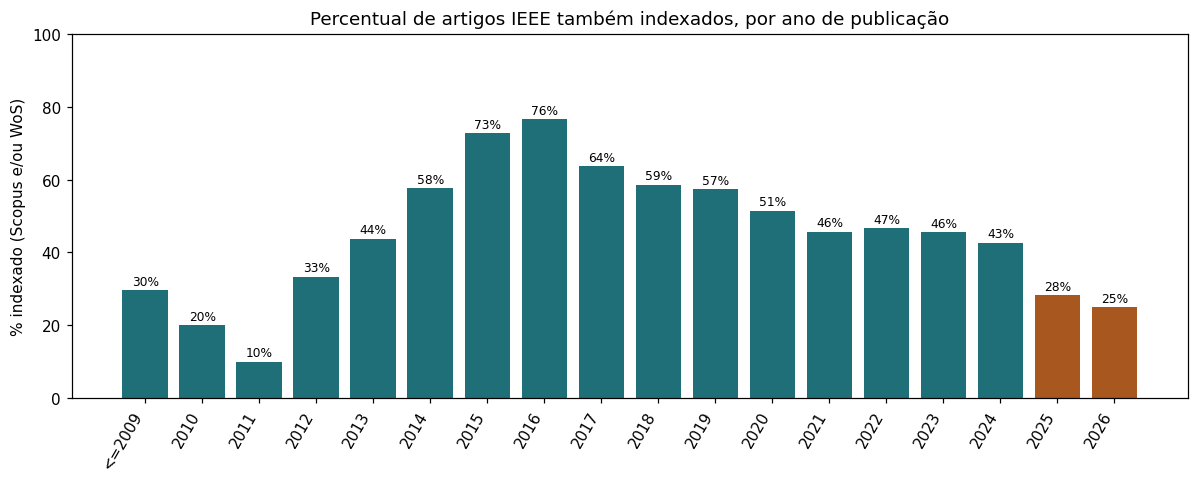

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
cores = ["#1f6f78" if str(i) not in ("2025", "2026") else "#a8571f" for i in por_ano.index]
ax.bar(por_ano.index.astype(str), por_ano["%"], color=cores)
ax.set_ylabel("% indexado (Scopus e/ou WoS)")
ax.set_title("Percentual de artigos IEEE também indexados, por ano de publicação")
ax.set_ylim(0, 100)
for i, v in enumerate(por_ano["%"]):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=8)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [13]:
ate_2023 = df_resultado[pd.to_numeric(df_resultado["ano"], errors="coerce") <= 2023]
de_2024 = df_resultado[pd.to_numeric(df_resultado["ano"], errors="coerce") >= 2024]

print(f"Artigos até 2023: {len(ate_2023)}, indexados: {ate_2023['indexado'].sum()} ({100*ate_2023['indexado'].mean():.1f}%)")
print(f"Artigos 2024+:    {len(de_2024)}, indexados: {de_2024['indexado'].sum()} ({100*de_2024['indexado'].mean():.1f}%)")

Artigos até 2023: 791, indexados: 399 (50.4%)
Artigos 2024+:    855, indexados: 284 (33.2%)


Restringindo aos artigos publicados **até 2023** — tempo suficiente para a indexação amadurecer — a sobreposição sobe para **50,4%**. Nos artigos de **2024 em diante**, cai para **33,2%**, puxada para baixo pelos registros de 2025 (28,2%) e 2026 (25,0%), ainda em processo de indexação pelas outras bases.

## 7. Por tipo de documento

82,6% da base IEEE consolidada é anais de congresso (`IEEE Conferences`), e congressos menores/regionais costumam ter cobertura mais irregular em Scopus/WoS do que periódicos.

In [14]:
def categoriza_tipo(t):
    t = str(t)
    if "Journal" in t or "Magazine" in t or "Early Access" in t:
        return "Periódicos e magazines"
    if "Conference" in t:
        return "Anais de congresso"
    return "Livros, capítulos e normas"


df_resultado["categoria_tipo"] = df_resultado["tipo_documento"].apply(categoriza_tipo)

por_tipo = df_resultado.groupby("categoria_tipo").agg(total=("indexado", "size"), indexado=("indexado", "sum"))
por_tipo["%"] = (100 * por_tipo["indexado"] / por_tipo["total"]).round(1)
por_tipo.sort_values("total", ascending=False)

,total,indexado,%
categoria_tipo,,,
Anais de congresso,1360,571,42.0
Periódicos e magazines,205,106,51.7
"Livros, capítulos e normas",81,6,7.4


## 8. Um viés adicional possível: strings de busca diferentes por base

Levantei essa possibilidade a partir de uma objeção legítima: a comparação acima só é justa se as três bases tiverem sido consultadas sobre os *mesmos* conceitos. Se a Scopus nunca foi perguntada sobre um tema que só foi buscado na IEEE, um artigo pode estar genuinamente indexado na Scopus e mesmo assim não aparecer na `base_scopus_consolidada.csv` — não porque a Scopus não o tenha, mas porque a busca da Scopus nunca cobriu aquele conceito (efeito "abracadabra": um termo que só entra na busca de uma base perde a chance de casamento na outra, por motivo do buscador/da estratégia de busca, não da indexação real).

As strings de busca de cada base estão documentadas em `informacoes_iniciais/palavras_chave_temac.md`. Comparando literalmente as 18 strings da IEEE, as 13 da Scopus e as 9 da WoS por conteúdo booleano (ignorando só o prefixo de campo — `TS=`, `TITLE-ABS-KEY()` ou nenhum prefixo na IEEE), a maioria dos conceitos foi buscada com a mesma redação nas três bases, mas não todos.

In [15]:
strings_compartilhadas = pd.DataFrame([
    {"conceito": "Data lake + on-premise/open source/híbrido + não estruturados/schema-on-read", "WoS": 21, "Scopus": 22, "IEEE": 14},
    {"conceito": "Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch", "WoS": 1270, "Scopus": 1836, "IEEE": 1051},
    {"conceito": "Data lake + open source/híbrido + big data", "WoS": 52, "Scopus": 99, "IEEE": 60},
    {"conceito": "Data lake + apoio à decisão + big data", "WoS": 95, "Scopus": 219, "IEEE": 81},
    {"conceito": "Data lake + não estruturados/heterogêneos/big data (geral)", "WoS": 1069, "Scopus": 1523, "IEEE": 588},
    {"conceito": "Data lake + IA/ML + batch/streaming + big data", "WoS": 21, "Scopus": 33, "IEEE": 35},
    {"conceito": "Data lake + IA/ML + apoio à decisão", "WoS": 93, "Scopus": 130, "IEEE": 51},
    {"conceito": "Fusão de dados + apoio à decisão + tempo real + militar/defesa (combo A)", "WoS": 37, "Scopus": 46, "IEEE": 50},
    {"conceito": "Data lake + big data + militar/defesa (combo B)", "WoS": 10, "Scopus": 16, "IEEE": 14},
])
print("Conceitos buscados com redação equivalente nas três bases (contagem documentada no momento da busca):")
strings_compartilhadas

Conceitos buscados com redação equivalente nas três bases (contagem documentada no momento da busca):


,conceito,WoS,Scopus,IEEE
0,Data lake + on-premise/open source/híbrido + não estruturados/schema-on-read,21,22,14
1,Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch,1270,1836,1051
2,Data lake + open source/híbrido + big data,52,99,60
3,Data lake + apoio à decisão + big data,95,219,81
4,Data lake + não estruturados/heterogêneos/big data (geral),1069,1523,588
5,Data lake + IA/ML + batch/streaming + big data,21,33,35
6,Data lake + IA/ML + apoio à decisão,93,130,51
7,Fusão de dados + apoio à decisão + tempo real + militar/defesa (combo A),37,46,50
8,Data lake + big data + militar/defesa (combo B),10,16,14


In [16]:
strings_exclusivas = pd.DataFrame([
    {"base": "IEEE", "conceito": "Data lake + militar/C2 + IA/ML", "contagem": 2},
    {"base": "IEEE", "conceito": "ETL/pipeline + geoespacial/GEOINT + operações militares/planejamento tático", "contagem": 0},
    {"base": "IEEE", "conceito": "Guerra centrada em rede + arquitetura/fusão de dados + edge computing", "contagem": 21},
    {"base": "IEEE", "conceito": "COP/sistema C2 + integração de dados/data lake + tempo real/apoio à decisão", "contagem": 1},
    {"base": "IEEE", "conceito": "Data lake + IA/ML + ETL/pipeline/ingestão", "contagem": 30},
    {"base": "IEEE", "conceito": "Data lake + geoespacial/sensoriamento remoto/GIS + modelo preditivo/análise espacial", "contagem": 1},
    {"base": "IEEE", "conceito": "Design Science Research + data lake/arquitetura/big data", "contagem": 59},
    {"base": "IEEE", "conceito": "Data lake + on-premise/open source/edge computing + não estruturados", "contagem": 13},
    {"base": "IEEE", "conceito": "Fusão de dados/sensores + análise em tempo real/streaming + apoio à decisão/consciência situacional", "contagem": 53},
    {"base": "Scopus", "conceito": "Data lake + militar/defesa/C2/forças armadas + IA/ML/apoio à decisão", "contagem": 13},
    {"base": "Scopus", "conceito": "Pipeline ETL/ingestão + geoespacial/terreno/GEOINT/sensoriamento remoto + militar/planejamento/consciência situacional", "contagem": 330},
    {"base": "Scopus", "conceito": "Guerra centrada em dados/rede/mission command + gestão de dados/fusão/informação", "contagem": 81},
    {"base": "Scopus", "conceito": "COP/gestão de campo de batalha + data lake/big data/plataforma de dados + apoio à decisão", "contagem": 5},
])
print("Conceitos buscados em apenas uma das bases (sem redação equivalente nas outras duas):")
print(f"IEEE exclusivo: {strings_exclusivas[strings_exclusivas['base']=='IEEE']['contagem'].sum()} resultados brutos, em 9 strings")
print(f"Scopus exclusivo: {strings_exclusivas[strings_exclusivas['base']=='Scopus']['contagem'].sum()} resultados brutos, em 4 strings")
print("WoS exclusivo: nenhuma string — todas as 9 buscas da WoS têm redação equivalente na Scopus e na IEEE")
strings_exclusivas

Conceitos buscados em apenas uma das bases (sem redação equivalente nas outras duas):
IEEE exclusivo: 180 resultados brutos, em 9 strings
Scopus exclusivo: 429 resultados brutos, em 4 strings
WoS exclusivo: nenhuma string — todas as 9 buscas da WoS têm redação equivalente na Scopus e na IEEE


,base,conceito,contagem
0,IEEE,Data lake + militar/C2 + IA/ML,2
1,IEEE,ETL/pipeline + geoespacial/GEOINT + operações militares/planejamento tático,0
2,IEEE,Guerra centrada em rede + arquitetura/fusão de dados + edge computing,21
3,IEEE,COP/sistema C2 + integração de dados/data lake + tempo real/apoio à decisão,1
4,IEEE,Data lake + IA/ML + ETL/pipeline/ingestão,30
5,IEEE,Data lake + geoespacial/sensoriamento remoto/GIS + modelo preditivo/análise ...,1
6,IEEE,Design Science Research + data lake/arquitetura/big data,59
7,IEEE,Data lake + on-premise/open source/edge computing + não estruturados,13
8,IEEE,Fusão de dados/sensores + análise em tempo real/streaming + apoio à decisão/...,53
9,Scopus,Data lake + militar/defesa/C2/forças armadas + IA/ML/apoio à decisão,13


### 8.1 Teste direto: quanto disso afeta o resultado?

A pergunta que importa não é "as strings diferem" (elas diferem, comprovadamente) — é **quantos dos 1.646 registros da base IEEE consolidada só poderiam ter sido encontrados por uma dessas 9 strings exclusivas da IEEE**. Esses registros são estruturalmente incomparáveis: não é razoável esperar que apareçam na Scopus/WoS exportadas, porque a Scopus/WoS nunca foram perguntadas sobre aquele conceito.

Isso dá para checar de verdade, porque os exports brutos de cada uma das 17 buscas da IEEE (uma por string, salvos individualmente antes da consolidação) ainda estão em `dados_brutos_IEEE_XPRES/`. Identifiquei qual arquivo bruto corresponde a qual string (por contagem de linhas batendo com a tabela do apêndice, conferido pelo conteúdo/tema dos títulos) e separei os 9 arquivos das strings **compartilhadas** dos 7 arquivos disponíveis das strings **exclusivas da IEEE** (a string "Design Science Research", com 59 resultados documentados, não tem arquivo correspondente nos brutos — ver seção 9).

In [17]:
pasta_ieee_bruto = "../../dados_brutos_IEEE_XPRES"

arquivos_compartilhados = [
    "export2026.02.20-18.42.07.csv",
    "export2026.02.20-18.44.57.csv",
    "export2026.02.20-18.46.06.csv",
    "export2026.02.20-18.46.33.csv",
    "export2026.02.20-18.47.06.csv",
    "export2026.02.20-18.47.30.csv",
    "export2026.02.20-18.47.55.csv",
    "export2026.02.20-18.48.20.csv",
    "export2026.02.20-18.48.55.csv",
]


def carrega_chaves(arquivos):
    dois, titulos = set(), set()
    for nome in arquivos:
        df = pd.read_csv(f"{pasta_ieee_bruto}/{nome}", encoding="utf-8")
        dois.update(norm_doi(d) for d in df["DOI"].dropna())
        dois.discard("")
        titulos.update(norm_title(t) for t in df["Document Title"].dropna())
        titulos.discard("")
    return dois, titulos


pool_doi_compartilhado, pool_titulo_compartilhado = carrega_chaves(arquivos_compartilhados)

df_resultado["alcancavel_por_busca_compartilhada"] = df_resultado.apply(
    lambda r: (norm_doi(r["doi"]) in pool_doi_compartilhado) or (norm_title(r["titulo"]) in pool_titulo_compartilhado),
    axis=1,
)

so_exclusiva = df_resultado[~df_resultado["alcancavel_por_busca_compartilhada"]]
compartilhavel = df_resultado[df_resultado["alcancavel_por_busca_compartilhada"]]

print(f"Total: {len(df_resultado)}")
print(f"Alcançáveis por pelo menos uma busca compartilhada (comparação justa): {len(compartilhavel)}")
print(f"  -> indexados na Scopus/WoS: {compartilhavel['indexado'].sum()} ({100*compartilhavel['indexado'].mean():.1f}%)")
print(f"Alcançáveis SÓ por busca exclusiva da IEEE (comparação não é justa para esses): {len(so_exclusiva)}")
print(f"  -> indexados na Scopus/WoS: {so_exclusiva['indexado'].sum()} ({100*so_exclusiva['indexado'].mean():.1f}%)")

Total: 1646
Alcançáveis por pelo menos uma busca compartilhada (comparação justa): 1586
  -> indexados na Scopus/WoS: 667 (42.1%)
Alcançáveis SÓ por busca exclusiva da IEEE (comparação não é justa para esses): 60
  -> indexados na Scopus/WoS: 16 (26.7%)


**Resultado do teste:** restringindo o cálculo aos 1.586 artigos que também poderiam, em princípio, ter sido encontrados pela Scopus/WoS (porque vieram de uma busca que existe nas três bases), a sobreposição fica em **42,1%** — praticamente igual aos 41,5% do cálculo original com todos os 1.646. Só 60 artigos (3,6% da base) vieram exclusivamente de strings que nunca foram buscadas na Scopus/WoS, e mesmo esses têm 26,7% de sobreposição (18 dos 60 aparecem lá mesmo assim, provavelmente porque satisfazem também alguma das buscas compartilhadas na Scopus/WoS, mesmo não tendo sido a via de entrada na IEEE).

**Conclusão desse teste:** a hipótese "abracadabra" é real em princípio e vale a pena ter checado, mas neste conjunto de dados ela não é a explicação para os 58,5% "não encontrados" — o efeito é pequeno (≈1,3 ponto percentual) porque a maior parte dos artigos da base IEEE veio das buscas *largas* ("data lake... AND big data", 588 resultados; "fusão/integração de dados... AND tempo real", 1.051 resultados), que têm equivalente exato na Scopus e na WoS. Os fatores que de fato explicam a maior parte da não-sobreposição continuam sendo os das seções 6 e 7: defasagem de indexação em artigos recentes e a alta proporção de anais de congresso.

## 9. Auditoria de completude: exports parciais/truncados

Comparando a contagem de resultados documentada no apêndice (no momento da busca) com o número de linhas efetivamente salvo em cada arquivo bruto, apareceram duas discrepâncias que não têm a ver com viés de comparação — são **exports incompletos**, provavelmente por causa do limite de tamanho de download mencionado (bases grandes precisam ser baixadas em partes).

In [18]:
auditoria = pd.DataFrame([
    {"base": "IEEE", "conceito": "Design Science Research + data lake/arquitetura/big data", "documentado": 59, "encontrado_no_bruto": 0, "obs": "nenhum arquivo bruto corresponde a essa busca — parece ter se perdido; o horário 18:40:51 tem um arquivo duplicado (mesmo título único da busca anterior, geoespacial), sugerindo reexportação por engano no lugar desta"},
    {"base": "IEEE", "conceito": "Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch", "documentado": 1051, "encontrado_no_bruto": 982, "obs": "faltam 69 registros (6,6%) — maior busca individual da IEEE, provável corte de export"},
    {"base": "Scopus", "conceito": "Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch (mesmo conceito acima)", "documentado": 1836, "encontrado_no_bruto": 1702, "obs": "faltam 134 registros (7,3%) — mesma busca, mesmo padrão de corte, agora na Scopus"},
])
auditoria

,base,conceito,documentado,encontrado_no_bruto,obs
0,IEEE,Design Science Research + data lake/arquitetura/big data,59,0,nenhum arquivo bruto corresponde a essa busca — parece ter se perdido; o hor...
1,IEEE,Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch,1051,982,"faltam 69 registros (6,6%) — maior busca individual da IEEE, provável corte ..."
2,Scopus,Fusão/integração de dados + apoio à decisão + tempo real/streaming/batch (me...,1836,1702,"faltam 134 registros (7,3%) — mesma busca, mesmo padrão de corte, agora na S..."


Note que é exatamente a **mesma busca conceitual** (fusão/integração de dados + apoio à decisão + tempo real) que aparece truncada tanto na IEEE quanto na Scopus — reforça que é um problema de exportação de resultados grandes (a plataforma provavelmente limita o tamanho do arquivo por download), não um problema pontual de uma base só. Os demais exports batem com a contagem documentada dentro de uma margem de 1 registro (esperado, já que os índices mudam entre o dia da busca-piloto documentada e o dia do download final).

**Isso é uma lacuna de completude da base, separada da questão do viés de busca** — e é corrigível com esforço pequeno e cirúrgico: não é preciso refazer as 18 buscas de novo, só re-exportar (em partes, se necessário) essas duas buscas específicas na IEEE e na Scopus, mais a busca "Design Science Research" que parece ter sido perdida por completo. Vale investigar/refazer antes da defesa, porque potencialmente adiciona ~260 registros à base (59 + 69 + 134, brutos, antes de deduplicação) que hoje simplesmente não estão em lugar nenhum.

## 10. Conclusão revisada — argumento para a banca

O dado não confirma "grande parte" no sentido literal, mas sustenta uma versão mais precisa e defensável do argumento original — e agora testada contra a objeção mais forte que se pode fazer a ele (viés de busca por palavra-chave diferente por base):

- **41,5%** dos artigos da IEEE Xplore aparecem também em Scopus e/ou WoS (19,0% nas duas simultaneamente); restringindo aos artigos que vieram de uma busca com redação equivalente nas três bases, o número sobe muito pouco, para **42,1%** — ou seja, a diferença de estratégia de busca entre plataformas **não** é a explicação principal da não-sobreposição;
- Entre artigos com tempo de maturação de indexação (**até 2023**), a sobreposição sobe para **50,4%**, chegando a **72–77%** nos anos de pico (2015–2016) — este é o efeito dominante;
- **82,6%** da base IEEE é anais de congresso, formato com cobertura mais irregular (42,0%) do que periódicos (51,7%) — segundo efeito dominante;
- separadamente, foi identificada uma lacuna de **completude** (não de viés): duas buscas grandes (IEEE e Scopus) foram exportadas truncadas, e uma busca da IEEE ("Design Science Research", 59 resultados documentados) não tem arquivo bruto correspondente — recomenda-se reexportar essas três buscas antes de fechar o número definitivo, mas o efeito esperado sobre o percentual agregado é pequeno diante da escala da base (1.646 registros).

O ponto levantado na qualificação continua válido **independentemente** desse percentual: a IEEE Xplore não fornece contagem de citações nem lista de artigos citantes, o que inviabiliza as métricas de acoplamento bibliográfico e cocitação centrais ao TEMAC — mesmo para o artigo que não está duplicado em Scopus/WoS.

**Frase-síntese para a banca:** *"Cerca de 40 a 50% dos artigos que a IEEE Xplore retornaria já são recuperados por Scopus e WoS — e esse número sobe para mais de 70% em janelas de tempo maduras, quando o atraso normal de indexação das bases já não pesa. Testei inclusive se essa sobreposição parcial seria só um artefato de eu ter usado strings de busca diferentes em cada base, e não é: restringindo a comparação só aos temas buscados de forma equivalente nas três bases, o percentual muda menos de 1 ponto. A fração da IEEE que realmente não se repete é majoritariamente anais de congresso recentes, sem contagem de citações própria — o que a torna pouco útil para a etapa bibliométrica do TEMAC mesmo quando não é redundante."*

## 11. Exportação da planilha artigo a artigo

Para poder responder a qualquer pergunta específica da banca sobre um artigo em particular.

In [19]:
colunas_export = [
    "titulo", "doi", "ano", "tipo_documento",
    "na_scopus", "metodo_scopus", "titulo_pareado_scopus",
    "na_wos", "metodo_wos", "titulo_pareado_wos",
]
df_resultado[colunas_export].to_csv("indexacao_ieee_vs_scopus_wos.csv", index=False, encoding="utf-8")
print("Salvo em indexacao_ieee_vs_scopus_wos.csv")

Salvo em indexacao_ieee_vs_scopus_wos.csv
